# Data Analysis Mathematics, Algorithms and Modeling

## Team Information - ** TODO Fill the type of assignment**

**Team Members**

Name: Ayush Patel  
Student Number: 9033358

Name: Nikhil Shankar  
Student Number: 9026254

Name: Sreehari Prathap  
Student Number: 8903199


## Step 1: Install and Configure the IDE (e.g., Jupyter Notebook and VS Code)
- Install Anaconda (for Jupyter Notebook) and Visual Studio Code (VS Code).
  - Anaconda: Visit [anaconda.com](https://www.anaconda.com/products/individual) and download the appropriate installer for your operating system.
  - VS Code: Download and install from [Visual Studio Code](https://code.visualstudio.com/).
- Install Pandas Library
  - Open the terminal and run the following command: `pip install pandas`

## Step 2: Downloading the Dataset
We are using the Utrecht Fairness Recruitment dataset from [Kaggle], which can be downloaded directly via the link:
- URL: [https://www.kaggle.com/datasets/ictinstitute/utrecht-fairness-recruitment-dataset]

## Step 3 : Data Cleansing

### Data Cleansing Process for User Data (Talent Acquisition) from a CSV File

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

file = "../data/Extended_Employee_Performance_and_Productivity_Data.csv"
df_unfiltered = pd.read_csv(file)
row_count = len(df_unfiltered)

print("Total number of datapoints(rows)", row_count)

Total number of datapoints(rows) 100000


##### Removing empty valued rows from the dataset
By giving axis as 0 we filter rows with any empty values. 

In [10]:
df = df_unfiltered.dropna(axis=0, how='any')
print("Total number of datapoints(rows)", len(df))

Total number of datapoints(rows) 100000


We understand that there are no rows with empty values. The dataset is now filtered for analysis so we can proceed to the next step. 

In [11]:
nullcounts = df.isnull().sum()
print(nullcounts)

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64


> There are no null values in any rows in any columns

#### **Dimensions**

In [12]:
print(df.shape)

(100000, 20)


- There are 20 columns. Means the count of dimension is 20. 
- Its a low number.
- The number of rows (100000) is very high compare to features. (20) So this can't be considered as high dimensional dataset.

#### **Missing Values Ratio**

- There are no rows with missing values and hence we don't need to apply this technique for this dataset.

#### **Low Variance Filter**

In [15]:
variance_list = df.select_dtypes(include=['number']).var().sort_values(ascending=True)
print(variance_list)

Promotions                     6.656466e-01
Employee_Satisfaction_Score    1.324155e+00
Performance_Score              2.001449e+00
Years_At_Company               8.233090e+00
Sick_Days                      1.876268e+01
Team_Size                      3.019948e+01
Overtime_Hours                 7.506535e+01
Work_Hours_Per_Week            7.995942e+01
Age                            1.264302e+02
Projects_Handled               2.093689e+02
Training_Hours                 8.346542e+02
Remote_Work_Frequency          1.249704e+03
Monthly_Salary                 1.883780e+06
Employee_ID                    8.333417e+08
dtype: float64


Before we do this step we need to scale the features.
We are using min max scaling

In [16]:
from sklearn.preprocessing import MinMaxScaler

numeric_df = df.select_dtypes(include=['number'])
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)
variance_sorted = scaled_df.var().sort_values()
print("Variance of each Min-Max scaled numeric column (sorted in ascending order):")
print(variance_sorted)

Variance of each Min-Max scaled numeric column (sorted in ascending order):
Monthly_Salary                 0.071026
Years_At_Company               0.082331
Employee_Satisfaction_Score    0.082760
Employee_ID                    0.083336
Training_Hours                 0.085160
Projects_Handled               0.087201
Age                            0.087556
Work_Hours_Per_Week            0.088844
Overtime_Hours                 0.089257
Team_Size                      0.093208
Sick_Days                      0.095728
Remote_Work_Frequency          0.124970
Performance_Score              0.125091
Promotions                     0.166412
dtype: float64


- Now we have the features sorted based on variance, We can see the range of variance is from 0.07-0.16 for range 0-1
- Only monthly salary has a very low variance and we can think about removing it. 
- We would keep it for furter analysis and if it is noted that its a candidate in further analysis we will choose to remove it.

#### **High Correlation Filter**

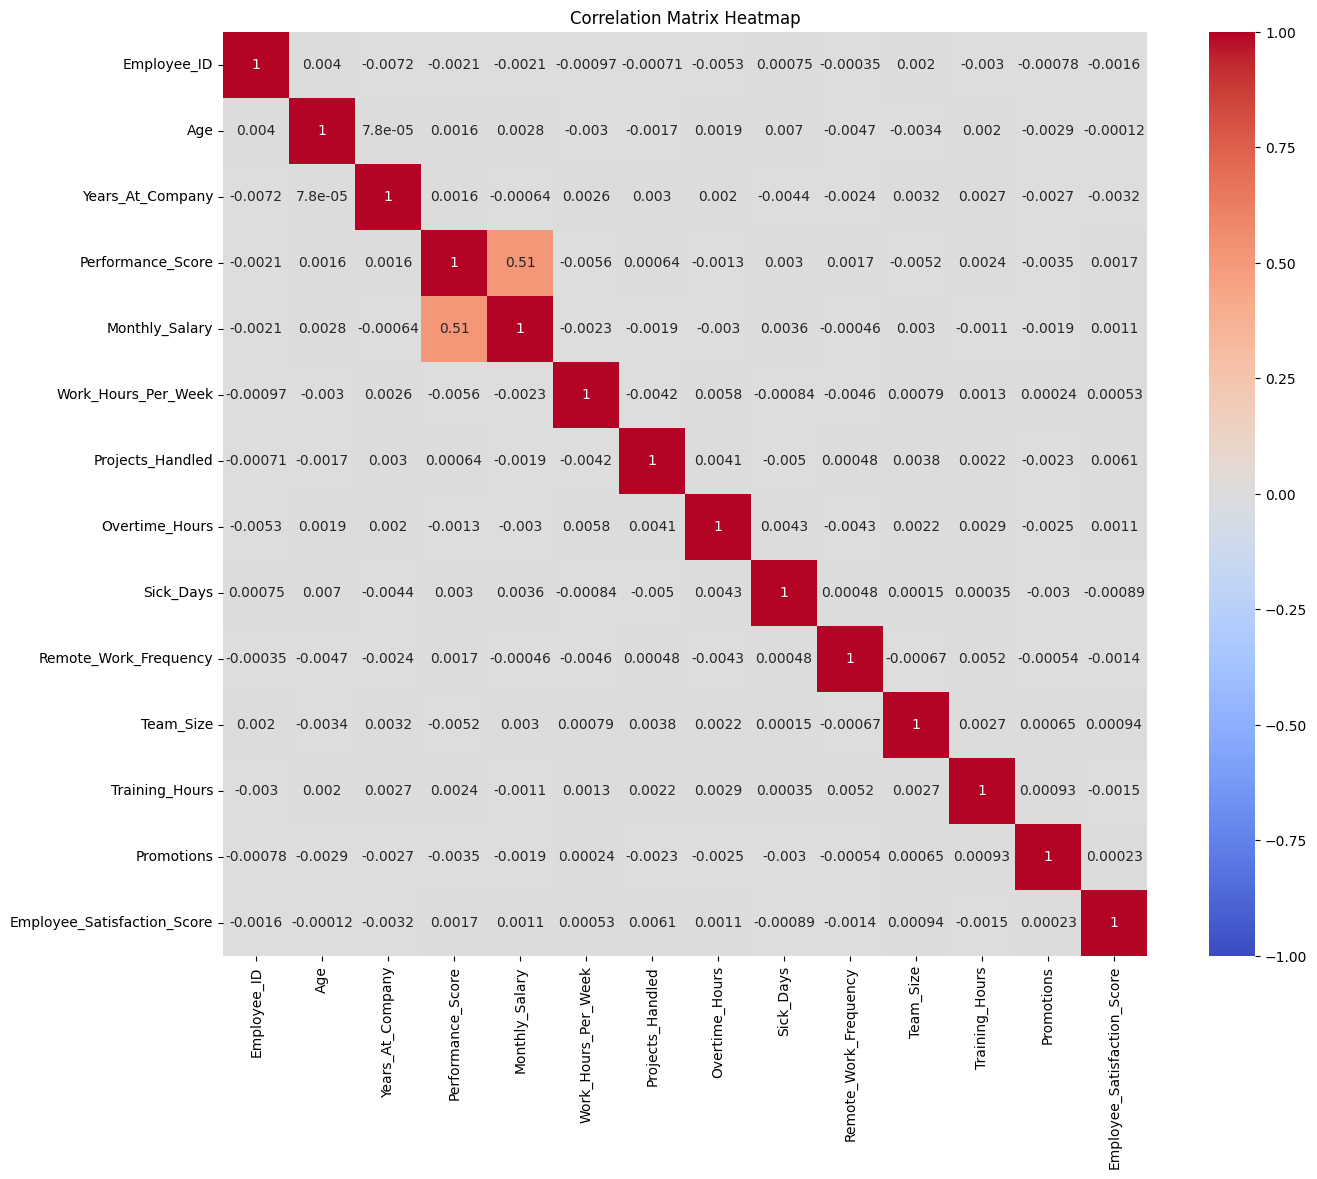

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.select_dtypes(include=['number']).corr()
# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)

# Display the heatmap
plt.title("Correlation Matrix Heatmap")
plt.show()

- We can see that Monthly Salary and Performance is highly correlated.
- In the previous step we noted that monthly salary has low variance. Hence at this point out of the two pairs we can remove monthly salary 

In [21]:
df_corr_removed = df.drop(columns = ['Monthly_Salary'])
print(df_corr_removed.shape)

(100000, 19)


#### **Principal Component Analysis**

In [32]:
from sklearn.decomposition import PCA

df_numeric = df.select_dtypes(include=['number']).corr()

df_numeric = df_numeric.drop(columns=['Employee_ID'])

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_numeric)
pca = PCA()
principal_components = pca.fit_transform(scaled_data)
# Step 3: Create a DataFrame of Principal Components
principal_df = pd.DataFrame(principal_components, columns=[f'PC{i+1}/{col_name}' for i, col_name in enumerate(df_numeric.columns)])

# Step 4: Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

print("Principal Components:")
display(principal_df)
print("\nExplained Variance Ratio:")
print(explained_variance)

Principal Components:


,PC1/Age,PC2/Years_At_Company,PC3/Performance_Score,PC4/Monthly_Salary,PC5/Work_Hours_Per_Week,PC6/Projects_Handled,PC7/Overtime_Hours,PC8/Sick_Days,PC9/Remote_Work_Frequency,PC10/Team_Size,PC11/Training_Hours,PC12/Promotions,PC13/Employee_Satisfaction_Score
0,-0.086396,0.003089,0.006239,0.002673,0.004855,0.001617,0.003814,0.004285,0.000035,-0.007523,0.001779,0.000874,0.271661
1,-0.151118,0.544546,0.088676,0.218553,-0.093847,0.526340,-0.058567,0.130910,0.108318,-0.433350,-0.213573,0.000568,-0.024745
2,-0.159329,-0.128582,-0.277326,-0.261262,-0.349678,0.340348,0.011593,0.499721,-0.198663,0.456118,-0.032680,-0.001788,-0.021364
3,0.940924,-0.006683,-0.006073,-0.004867,-0.001215,-0.001311,-0.008533,-0.007713,-0.003830,0.000512,-0.000609,0.345094,-0.009806
4,0.942520,-0.005166,-0.010104,-0.009332,0.006753,-0.003063,0.005792,-0.004921,0.002900,-0.007593,-0.001852,-0.344604,-0.009081
5,-0.178680,0.088352,-0.358916,-0.446130,0.266557,-0.310776,-0.309887,0.244125,0.096942,-0.395777,0.268768,0.001966,-0.023492
6,-0.166665,-0.373086,-0.184214,0.446304,-0.248298,0.109925,-0.024856,-0.220758,-0.280207,-0.261717,0.505338,-0.001960,-0.022957
7,-0.175999,0.218206,-0.373539,-0.021593,-0.087983,-0.255401,-0.087861,-0.498169,-0.363262,0.107075,-0.482690,-0.001425,-0.021136
8,-0.146990,0.569436,0.234106,0.097588,0.042873,-0.284295,0.309864,0.027555,-0.101881,0.343801,0.454647,0.000139,-0.023559
9,-0.155381,-0.241961,0.634548,-0.003653,-0.172504,-0.360117,-0.124129,0.280270,-0.286605,-0.195208,-0.267274,-0.001704,-0.023911



Explained Variance Ratio:
[0.16881786 0.08274199 0.08219741 0.08172664 0.0815206  0.08053184
 0.08026064 0.07980342 0.07953926 0.07859355 0.07842931 0.01934743
 0.00649003]


- We can see that none of the columsn have high pca variance ratio.
- Pointing to the fact that there are no major features which contribute to the overall variance of the dataset.
- Employee Satisfaction score can be seen as displaying very low PCA value so we can remove it.


#### **Random Forest Trees**

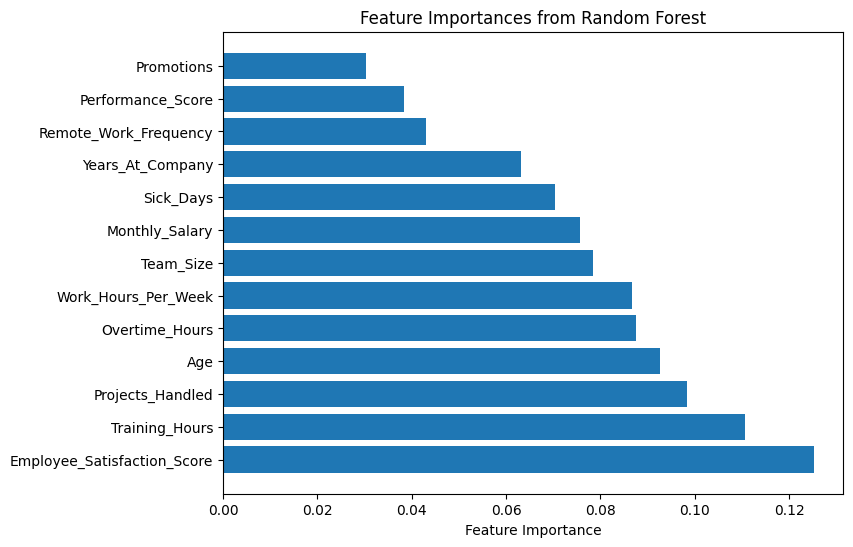

Selected features based on importance: Index(['Employee_Satisfaction_Score', 'Training_Hours', 'Projects_Handled',
       'Age', 'Overtime_Hours', 'Work_Hours_Per_Week', 'Team_Size',
       'Monthly_Salary', 'Sick_Days', 'Years_At_Company'],
      dtype='object')


In [44]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


# Define features and target
df_numeric_rft = df.drop(columns=['Employee_ID'])
df_numeric_rft = df_numeric_rft.select_dtypes(include=['number'])
X = df_numeric_rft
y = df['Resigned'].astype(int)  # Target (dependent variable)

# Step 1: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 2: Fit a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 3: Extract feature importances
feature_importances = rf.feature_importances_

# Step 4: Sort the features by importance
sorted_idx = feature_importances.argsort()[::-1]

# Step 5: Plot the feature importances
plt.figure(figsize=(8, 6))
plt.barh(X.columns[sorted_idx], feature_importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importances from Random Forest')
plt.show()

# Step 6: Select top N important features
# For example, select the top 2 most important features
top_n = 10
selected_features = X.columns[sorted_idx][:top_n]
X_selected = X[selected_features]

print("Selected features based on importance:", selected_features)

- We can see that Promotions, Performance_Score , Remote_Work_Frequency and Years_At_Company are the least impactful in predicting resignation.